# Publication-Ready Figure: Longitudinal Sampling Structure (Chapter 3, §3.2)

Reads `cohort_manifest.csv` for each cohort directly (`DATA/{DELCODE,ADNI,OASIS3}/
__metadata__/cohort_manifest.csv`, the schema documented in `DATA/manifest/schema.py`)
and the DELCODE-only downstream held-out test split
(`DATA/DELCODE/__metadata__/SPLITS/downstream/test.csv`).

Panels A and B use the full raw manifest -- every recorded visit across every diagnostic
group, not the narrower subject-level modelling cohort -- so they show the general
sampling-structure pattern the section describes, not the exact `tab:interval-structure`
percentages (which are computed over a narrower, modelling-relevant visit subset).

1. **Figure 9: Longitudinal Sampling Structure** (`fig9_longitudinal_sampling.pdf`)


In [1]:
import json, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Global publication style settings (.claude/rules/plots.md)
plt.rcParams.update({
    'font.family': 'Courier New',
    'font.size': 8,
    'axes.labelsize': 8.5,
    'xtick.labelsize': 7.5,
    'ytick.labelsize': 7.5,
    'legend.fontsize': 7.5,
    'axes.linewidth': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3.5,
    'ytick.major.size': 3.5,
    'legend.frameon': False,
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})

MM = 1 / 25.4

# Okabe-Ito colorblind-safe categorical palette for the three cohorts (Panels A, B).
COLOR_DELCODE = '#0072B2'   # Blue
COLOR_ADNI = '#D55E00'      # Vermillion
COLOR_OASIS3 = '#009E73'    # Bluish green

# Two-hue Teal / Purple palette for the binary converter/stable contrast (Panel C),
# consistent with the rest of the thesis.
COLOR_STABLE_FILL, COLOR_STABLE_EDGE = '#2ba099', '#14605b'      # Teal
COLOR_CONVERTER_FILL, COLOR_CONVERTER_EDGE = '#873397', '#50165b'  # Purple

_REPO_ROOT = Path(__file__).resolve().parents[2] if '__file__' in globals() else Path(os.getcwd() if not os.getcwd().endswith('plots_notebooks') else Path(os.getcwd()).parents[1])
OUTPUT_DIRS = [
    _REPO_ROOT / 'THESIS' / 'figures',
    _REPO_ROOT / 'DOCS' / 'results' / 'figures',
]
for d in OUTPUT_DIRS:
    d.mkdir(parents=True, exist_ok=True)

print('✓ Environment initialized and output directories ready.')


✓ Environment initialized and output directories ready.


## Ingest: raw cohort manifests


In [2]:
MANIFEST_PATHS = {
    'DELCODE': _REPO_ROOT / 'DATA' / 'DELCODE' / '__metadata__' / 'cohort_manifest.csv',
    'ADNI': _REPO_ROOT / 'DATA' / 'ADNI' / '__metadata__' / 'cohort_manifest.csv',
    'OASIS3': _REPO_ROOT / 'DATA' / 'OASIS3' / '__metadata__' / 'cohort_manifest.csv',
}

manifests = {}
for cohort, path in MANIFEST_PATHS.items():
    df = pd.read_csv(path).dropna(subset=['days_from_baseline'])
    manifests[cohort] = df
    print(f'{cohort}: {df["subject_id"].nunique()} subjects, {len(df)} recorded visits '
          f'(dropped {pd.read_csv(path)["days_from_baseline"].isna().sum()} rows with missing day)')


DELCODE: 840 subjects, 1177 recorded visits (dropped 9 rows with missing day)
ADNI: 268 subjects, 674 recorded visits (dropped 0 rows with missing day)
OASIS3: 128 subjects, 234 recorded visits (dropped 0 rows with missing day)


## Panel A: per-subject visit timelines

A reproducible random sample of 50 subjects per cohort (seed 42), rows ordered by number
of visits for a legible step pattern. x-axis: months from baseline
($\text{days\_from\_baseline} / 30.44$, the same day-to-month convention used throughout
§3.2).


In [3]:
N_SAMPLE = 50
rng = np.random.default_rng(42)

panel_a_data = {}
for cohort, df in manifests.items():
    subj_ids = df['subject_id'].unique()
    n = min(N_SAMPLE, len(subj_ids))
    sample_ids = rng.choice(subj_ids, size=n, replace=False)
    sub = df[df['subject_id'].isin(sample_ids)].copy()
    sub['months'] = sub['days_from_baseline'] / 30.44
    n_visits = sub.groupby('subject_id').size().sort_values()
    order = {sid: i for i, sid in enumerate(n_visits.index)}
    sub['row'] = sub['subject_id'].map(order)
    panel_a_data[cohort] = sub
    print(f'{cohort}: sampled {n} of {len(subj_ids)} subjects for Panel A')


DELCODE: sampled 50 of 840 subjects for Panel A
ADNI: sampled 50 of 268 subjects for Panel A
OASIS3: sampled 50 of 128 subjects for Panel A


## Panel B: inter-visit intervals

Consecutive-visit differences per subject (subjects with $\geq 2$ visits), converted to
months by the same $/30.44$ convention.


In [4]:
def inter_visit_intervals(df):
    df = df.sort_values(['subject_id', 'visit_index'])
    counts = df.groupby('subject_id').size()
    multi = counts[counts >= 2].index
    out = []
    for sid, g in df[df['subject_id'].isin(multi)].groupby('subject_id'):
        d = g.sort_values('visit_index')['days_from_baseline'].values
        out.extend((np.diff(d) / 30.44).tolist())
    return np.array(out)

panel_b_data = {cohort: inter_visit_intervals(df) for cohort, df in manifests.items()}
for cohort, intervals in panel_b_data.items():
    print(f'{cohort}: {len(intervals)} inter-visit intervals, median {np.median(intervals):.1f} mo, '
          f'mean {intervals.mean():.1f} mo')


DELCODE: 337 inter-visit intervals, median 12.2 mo, mean 14.2 mo
ADNI: 406 inter-visit intervals, median 12.2 mo, mean 13.3 mo
OASIS3: 106 inter-visit intervals, median 32.0 mo, mean 36.3 mo


## Panel C: visit count as a label proxy (DELCODE downstream held-out test split)

Two quantities for the same 34 held-out test subjects: total recorded visits across the
full clinical record (from the raw manifest), and the visits actually available to a
sequence model once a converter's post-conversion visits are excluded (the `n_scans`
column of `test.csv`, already leakage-truncated).


In [5]:
test_split = pd.read_csv(_REPO_ROOT / 'DATA' / 'DELCODE' / '__metadata__' / 'SPLITS' / 'downstream' / 'test.csv')
delcode_manifest = manifests['DELCODE']

conv_ids = test_split[test_split['converter_status'] == 1]['Pseudonym'].tolist()
stable_ids = test_split[test_split['converter_status'] == 0]['Pseudonym'].tolist()

total_recorded_conv = delcode_manifest[delcode_manifest['subject_id'].isin(conv_ids)].groupby('subject_id').size()
total_recorded_stable = delcode_manifest[delcode_manifest['subject_id'].isin(stable_ids)].groupby('subject_id').size()

preconv_scans_conv = test_split[test_split['converter_status'] == 1]['n_scans']
preconv_scans_stable = test_split[test_split['converter_status'] == 0]['n_scans']

panel_c_summary = pd.DataFrame({
    'Total recorded visits': [total_recorded_conv.mean(), total_recorded_stable.mean()],
    'Pre-conversion model input': [preconv_scans_conv.mean(), preconv_scans_stable.mean()],
}, index=['Converter (n=14)', 'Stable MCI (n=20)'])
panel_c_summary


,Total recorded visits,Pre-conversion model input
Converter (n=14),3.714286,2.571429
Stable MCI (n=20),2.350000,2.350000


### Cross-check against §3.2 prose


In [6]:
assert abs(total_recorded_conv.mean() - 3.7142857142857144) < 1e-9, 'total recorded converter mean does not match prose (3.71)'
assert abs(total_recorded_stable.mean() - 2.35) < 1e-9, 'total recorded stable mean does not match prose (2.35)'
assert abs(preconv_scans_conv.mean() - 2.5714285714285716) < 1e-9, 'pre-conversion converter mean does not match test.csv (2.57)'
assert abs(preconv_scans_stable.mean() - 2.35) < 1e-9, 'pre-conversion stable mean does not match test.csv (2.35)'
print('✓ Total recorded visits (3.71 / 2.35) and pre-conversion model-input scans (2.57 / 2.35) '
      'both match their respective sources exactly.')


✓ Total recorded visits (3.71 / 2.35) and pre-conversion model-input scans (2.57 / 2.35) both match their respective sources exactly.


## Figure 9: assemble panels A, B, C


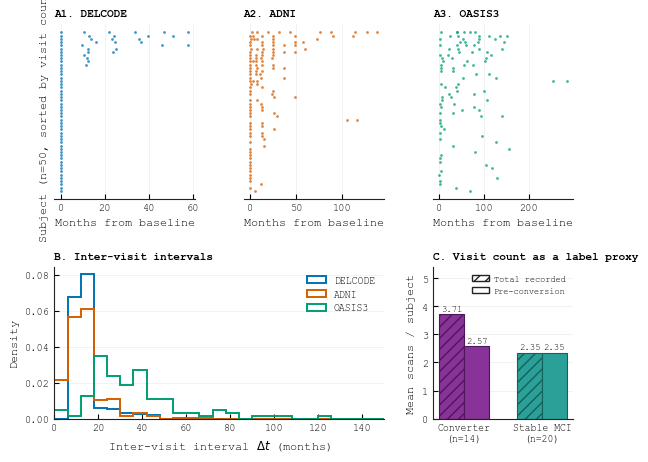

✓ Figure 9 saved successfully.


In [7]:
fig = plt.figure(figsize=(170 * MM, 130 * MM))
gs = fig.add_gridspec(2, 3, height_ratios=[1.15, 1], hspace=0.42, wspace=0.35)

cohorts = ['DELCODE', 'ADNI', 'OASIS3']
cohort_colors = {'DELCODE': COLOR_DELCODE, 'ADNI': COLOR_ADNI, 'OASIS3': COLOR_OASIS3}

# --- Panel A: per-subject visit timelines ---
for i, cohort in enumerate(cohorts):
    ax = fig.add_subplot(gs[0, i])
    sub = panel_a_data[cohort]
    ax.scatter(sub['months'], sub['row'], s=4, color=cohort_colors[cohort], alpha=0.75, linewidth=0)
    ax.set_title(f'A{i+1}. {cohort}', fontsize=8, fontweight='bold', loc='left')
    ax.set_xlabel('Months from baseline')
    if i == 0:
        ax.set_ylabel(f'Subject (n={N_SAMPLE}, sorted by visit count)')
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.spines['bottom'].set_color('#222222')
    ax.grid(axis='x', linestyle='-', alpha=0.15, color='#888888', linewidth=0.5)
    ax.set_axisbelow(True)

# --- Panel B: inter-visit interval histograms ---
ax_b = fig.add_subplot(gs[1, 0:2])
bins = np.arange(0, 200, 6)
for cohort in cohorts:
    ax_b.hist(panel_b_data[cohort], bins=bins, histtype='step', linewidth=1.4,
              color=cohort_colors[cohort], label=cohort, density=True)
ax_b.set_title('B. Inter-visit intervals', fontsize=8, fontweight='bold', loc='left')
ax_b.set_xlabel(r'Inter-visit interval $\Delta t$ (months)')
ax_b.set_ylabel('Density')
ax_b.set_xlim(0, 150)
ax_b.legend(loc='upper right', fontsize=7)
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)
ax_b.spines['left'].set_linewidth(0.8)
ax_b.spines['bottom'].set_linewidth(0.8)
ax_b.spines['left'].set_color('#222222')
ax_b.spines['bottom'].set_color('#222222')
ax_b.grid(axis='y', linestyle='-', alpha=0.15, color='#888888', linewidth=0.5)
ax_b.set_axisbelow(True)

# --- Panel C: visit count as a label proxy ---
ax_c = fig.add_subplot(gs[1, 2])
x = np.arange(2)
width = 0.32
totals = [total_recorded_conv.mean(), total_recorded_stable.mean()]
preconv = [preconv_scans_conv.mean(), preconv_scans_stable.mean()]
colors = [COLOR_CONVERTER_FILL, COLOR_STABLE_FILL]
edges = [COLOR_CONVERTER_EDGE, COLOR_STABLE_EDGE]

bars1 = ax_c.bar(x - width/2, totals, width, color=colors, edgecolor=edges, linewidth=0.8,
                  hatch='///', label='Total recorded')
bars2 = ax_c.bar(x + width/2, preconv, width, color=colors, edgecolor=edges, linewidth=0.8,
                  label='Pre-conversion')
for rects in (bars1, bars2):
    for r in rects:
        ax_c.text(r.get_x() + r.get_width() / 2, r.get_height() + 0.06, f'{r.get_height():.2f}',
                   ha='center', va='bottom', fontsize=6.5)

ax_c.set_title('C. Visit count as a label proxy', fontsize=8, fontweight='bold', loc='left')
ax_c.set_ylabel('Mean scans / subject')
ax_c.set_xticks(x)
ax_c.set_xticklabels(['Converter\n(n=14)', 'Stable MCI\n(n=20)'], fontsize=7)
ax_c.set_ylim(0, 5.4)
ax_c.set_yticks(np.arange(0, 6, 1))

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='white', edgecolor='#222222', hatch='///', label='Total recorded'),
    Patch(facecolor='white', edgecolor='#222222', label='Pre-conversion'),
]
ax_c.legend(handles=legend_handles, loc='upper right', fontsize=6.2, handletextpad=0.5,
            borderaxespad=0.5)

ax_c.spines['top'].set_visible(False)
ax_c.spines['right'].set_visible(False)
ax_c.spines['left'].set_linewidth(0.8)
ax_c.spines['bottom'].set_linewidth(0.8)
ax_c.spines['left'].set_color('#222222')
ax_c.spines['bottom'].set_color('#222222')
ax_c.grid(axis='y', linestyle='-', alpha=0.15, color='#888888', linewidth=0.5)
ax_c.set_axisbelow(True)

for out_dir in OUTPUT_DIRS:
    fig.savefig(out_dir / 'fig9_longitudinal_sampling.pdf', facecolor='white', edgecolor='none')
    fig.savefig(out_dir / 'fig9_longitudinal_sampling.png', dpi=600, facecolor='white', edgecolor='none')

plt.show()
print('✓ Figure 9 saved successfully.')
